# Figure 1C. Attributes of UHVDB

### Load mining reports

In [1]:
### Load original mining report (genomad, checkv, and viralverify joined outputs)
import polars as pl

original_mine_report = pl.read_csv('viruses.csvtk_concat.tsv', separator='\t', null_values='NA')

viruses_w_source = (
    original_mine_report
        .filter(
            (pl.col('kmer_freq') <= 1.2) & 
            (
                ((~pl.col('warningsPrediction').str.contains('>1 viral region detected')) & (~pl.col('warningsPrediction').str.contains('contig >1.5x longer'))) |
                (pl.col('warningsPrediction').is_null())
            ) &
            ((pl.col('completeness') >= 50) | (pl.col('contig_length') >= 10000)) &
            (pl.col('taxonomy') != 'Unclassified') &
            ((pl.col('taxonomy').str.contains('viricetes')) | (pl.col('taxonomy').str.contains('Anelloviridae')))
        )
        .with_columns([
            pl.when(pl.col('source_db').is_not_null()).then(pl.col('source_db'))
                .when(pl.col('seq_name').str.contains('\.contig')).then(pl.lit('ATB'))
                .when(pl.col('seq_name').str.contains('@')).then(pl.lit('CHVD'))
                .when(pl.col('seq_name').str.contains(r'^v\d')).then(pl.lit('CNGVC'))
                .when(pl.col('seq_name').str.contains('_vae_')).then(pl.lit('CNGVR'))
                .when(pl.col('seq_name').str.contains(r'^ERZ')).then(pl.lit('ENA'))
                .when(pl.col('seq_name').str.contains(r'^IMGVR')).then(pl.lit('IMGVR'))
                .when(pl.col('seq_name').str.contains(r'_round')).then(pl.lit('MMGE'))
                .when(pl.col('seq_name').str.contains(r'^(S|E|D)RR\d+_\d+$')).then(pl.lit('LOGAN'))
                .when(pl.col('seq_name').str.contains(r'^(S|E|D)RR\d+_\d+\|provirus')).then(pl.lit('LOGAN'))
                .when(pl.col('seq_name').str.contains(r'^opdg_')).then(pl.lit('OPD'))
                .when(pl.col('seq_name').str.contains(r'_cf_k')).then(pl.lit('PRJ'))
                .when(pl.col('seq_name').str.contains(r'^SMGC_')).then(pl.lit('SMGC'))
                .when(pl.col('seq_name').str.contains(r'_k\d+_\d+$')).then(pl.lit('SPIRE'))
                .when(pl.col('seq_name').str.contains(r'_k\d+_\d+\|provirus')).then(pl.lit('SPIRE'))
                .when(pl.col('seq_name').str.contains(r'^[a-zA-Z0-9]+\.k1.1_\d+')).then(pl.lit('VMGC'))
                .when(pl.col('seq_name').str.contains(r'_\d+\.k\d+_\d+')).then(pl.lit('OVD'))
                .alias('source_db')
        ])
        .filter(pl.col('uhvdb_virus_classification') != 'non-viral')
)

<>:20: SyntaxWarning: invalid escape sequence '\.'
<>:20: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_37156/4111993340.py:20: SyntaxWarning: invalid escape sequence '\.'
  .when(pl.col('seq_name').str.contains('\.contig')).then(pl.lit('ATB'))


In [30]:
### Load outputs from final UHVDB mining
seqhasher_ids = set(
    pl.read_csv('uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')
        ['original_id']
)
seqhasher_ids2 = set(
    pl.read_csv('uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')
        .with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id")))
        ['original_id']
)
print("Number of unique UHVDB IDs:", len(seqhasher_ids))

Number of unique UHVDB IDs: 760693


In [31]:
### Identify input viruses present in UHVDB
viruses_in_uhvdb = (
    viruses_w_source
        .filter(
            (pl.col('seq_name').is_in(seqhasher_ids)) |
            (pl.col('seq_name').is_in(seqhasher_ids2))
        )
)
print("Number of non-UHGV viruses in UHVDB:", viruses_in_uhvdb.unique('seq_name').height)

Number of non-UHGV viruses in UHVDB: 556605


In [32]:
### Identify UHGV viruses present in UHVDB
uhgv_in_uhvdb = (
    pl.read_csv('uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')
        .filter(pl.col('original_id').str.starts_with('UHGV'))
)
print("Number of UHGV viruses in UHVDB:", uhgv_in_uhvdb.unique('original_id').height)
print("Total UHVDB sequences with a source:", viruses_in_uhvdb.unique('seq_name').height + uhgv_in_uhvdb.unique('original_id').height)

Number of UHGV viruses in UHVDB: 204088
Total UHVDB sequences with a source: 760693


In [36]:
### Count UHVDB viruses by source
pl.Config.set_tbl_rows(15)
uhvdb_w_source = (
    pl.concat([viruses_in_uhvdb[['seq_name', 'source_db']], uhgv_in_uhvdb[['original_id']].rename({'original_id': 'seq_name'}).with_columns(pl.lit('UHGV').alias('source_db'))])
)
uhvdb_w_source.group_by('source_db').len().sort('len', descending=True)

source_db,len
str,u32
"""UHGV""",204088
"""SPIRE""",134570
"""IMGVR""",133028
"""OPD""",50425
"""CNGVC""",48199
"""MMGE""",47724
"""ENA""",46871
"""CNGVR""",32788
"""CHVD""",28636


### Annotate sequences with human body site

In [38]:
### annotate ENA sequences with body site
ena_meta = pl.read_csv('ena_human_samplesheet.csv.gz')

# create set of ena oral samples
ena_oral_samples = set(
    ena_meta
        .filter(
            (pl.col('scientific_name').str.contains('oral')) |
            (pl.col('scientific_name').str.contains('nasopharyngeal')) |
            (pl.col('scientific_name').str.contains('lung')) |
            (pl.col('scientific_name').str.contains('saliva '))
        )['sample']
)

ena_skin_samples = set(
    ena_meta
        .filter(
            (pl.col('scientific_name').str.contains('skin'))
        )['sample']
)

ena_urogenital_samples = set(
    ena_meta
        .filter(
            (pl.col('scientific_name').str.contains('vaginal ')) |
            (pl.col('scientific_name').str.contains('urinary'))
        )['sample']
)

In [39]:
### annotate Loagn sequences with body site
logan_meta = (
    pl.read_csv('logan_human_samplesheet.csv.gz')
)

# create set of logan oral samples
logan_oral_samples = set(
    logan_meta
        .filter(
            (pl.col('organism').str.contains('human oral metagenome')) |
            (pl.col('organism').str.contains('human nasopharyngeal metagenome')) |
            (pl.col('organism').str.contains('oral metagenome')) |
            (pl.col('organism').str.contains('respiratory tract metagenome')) |
            (pl.col('organism').str.contains('human lung metagenome')) |
            (pl.col('organism').str.contains('human saliva metagenome')) |
            (pl.col('organism').str.contains('upper respiratory tract metagenome')) |
            (pl.col('organism').str.contains('human sputum metagenome')) |
            (pl.col('organism').str.contains('lung metagenome')) |
            (pl.col('organism').str.contains('human tracheal metagenome')) |
            (pl.col('organism').str.contains('oral-nasopharyngeal metagenome'))
        )['acc']
)

logan_skin_samples = set(
    logan_meta
        .filter(
            (pl.col('organism').str.contains('human skin metagenome')) |
            (pl.col('organism').str.contains('skin metagenome'))
        )['acc']
)

logan_urogenital_samples = set(
    logan_meta
        .filter(
            (pl.col('organism').str.contains('human vaginal metagenome')) |
            (pl.col('organism').str.contains('vaginal metagenome')) |
            (pl.col('organism').str.contains('human urinary tract metagenome')) |
            (pl.col('organism').str.contains('urinary tract metagenome')) |
            (pl.col('organism').str.contains('human reproductive system metagenome')) |
            (pl.col('organism').str.contains('reproductive system metagenome'))
        )['acc']
)

In [40]:
### annotate SPIRE sequences with body site
# load spire microontoloy
spire_ont = (
    pl.read_csv("https://swifter.embl.de/~fullam/spire/metadata/spire_v1_microntology.tsv.gz", separator="\t", has_header=False)
    .with_columns(
        pl.col("column_1").str.splitn(by=" ", n=3)
        .struct.rename_fields(["biosample", "bioproject", "ontology"])
        .alias("fields")
    ).unnest("fields")
)

# filter to human airways, skin, and urogenital samples
spire_human = (
    spire_ont
        .filter(
            (pl.col("ontology").str.contains("animal host")) &
            (
                (pl.col("ontology").str.contains("mouth")) |
                (pl.col("ontology").str.contains("airway")) |
                (pl.col("ontology").str.contains("urogenital")) |
                (pl.col("ontology").str.contains("skin"))
            )
        )
        .unique('biosample')
)

# create set of spire oral samples
spire_oral_samples = set(
    spire_human
        .filter(
            (pl.col("ontology").str.contains("animal host")) &
            (
                (pl.col("ontology").str.contains("mouth")) |
                (pl.col("ontology").str.contains("airway"))
            )
        )['biosample']
)

# create set of ena skin samples
spire_skin_samples = set(
    spire_human
        .filter(
            (pl.col("ontology").str.contains("animal host")) &
            (
                (pl.col("ontology").str.contains("skin"))
            )
        )['biosample']
)

# create set of ena urogenital samples
spire_urogenital_samples = set(
    spire_human
        .filter(
            (pl.col("ontology").str.contains("animal host")) &
            (
                (pl.col("ontology").str.contains("urogenital"))
            )
        )['biosample']
)

In [41]:
### annotate IMGVR sequences with body site
imgvr_meta = pl.read_csv('IMGVR_all_Sequence_information.tsv',
    separator='\t', columns=['UVIG', 'Ecosystem classification'])

# identify human samples
(
    imgvr_meta
        .filter(
            (pl.col('Ecosystem classification').str.contains('Human'))
        )
        .group_by('Ecosystem classification')
        .len()
        .sort(pl.col('len'), descending=True)
        .write_csv('IMGVR_human_ecosystem_classification_counts.csv')
)

imgvr_human_uvigs = (
    imgvr_meta
        .filter(
            (pl.col('Ecosystem classification').str.contains('Human'))
        )
)

# create set of imgvr gut samples
imgvr_gut_samples = set(
    imgvr_human_uvigs
        .filter(
            (
                (pl.col("Ecosystem classification").str.contains("intestine"))
            )
        )['UVIG']
)

# create set of imgvr oral samples
imgvr_oral_samples = set(
    imgvr_human_uvigs
        .filter(
            (
                (pl.col("Ecosystem classification").str.contains("Oral")) |
                (pl.col("Ecosystem classification").str.contains("Pharynx")) |
                (pl.col("Ecosystem classification").str.contains("Sputum")) |
                (pl.col("Ecosystem classification").str.contains("Tonsils")) |
                (pl.col("Ecosystem classification").str.contains("Nasal")) |
                (pl.col("Ecosystem classification").str.contains("Trachea")) |
                (pl.col("Ecosystem classification").str.contains("Lung")) |
                (pl.col("Ecosystem classification").str.contains("Throat"))
            )
        )['UVIG']
)

# create set of imgvr skin samples
imgvr_skin_samples = set(
    imgvr_human_uvigs
        .filter(
            (
                (pl.col("Ecosystem classification").str.contains("Skin"))
            )
        )['UVIG']
)

# create set of spire urogenital samples
imgvr_urogenital_samples = set(
    imgvr_human_uvigs
        .filter(
            (
                (pl.col("Ecosystem classification").str.contains("Vagina")) |
                (pl.col("Ecosystem classification").str.contains("Urine")) |
                (pl.col("Ecosystem classification").str.contains("Urethra")) |
                (pl.col("Ecosystem classification").str.contains("Uterus")) |
                (pl.col("Ecosystem classification").str.contains("Urinary"))
            )
        )['UVIG']
)

In [ ]:
%%bash
### get mmge information
wget wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
unzip all_mge_inf.zip
wget https://mai.fudan.edu.cn/mgedb/client/file/all_sample_inf.zip
unzip all_sample_inf.zip

In [42]:
### annotate MMGE sequences with body site
mmge_meta = (
    pl.read_csv('all_mge_inf.csv')
        .with_columns([
            pl.col('sam_ids').str.split(',')
        ])
)

mmge_sample_meta = pl.read_csv('sampleInfo.csv')

# identify body site for each sample
mmge_gut_samples = set(
    mmge_sample_meta
        .filter(
            (pl.col('BodySite').str.contains('Gut'))
        )['NCBI_Run_ID']
)

mmge_oral_samples = set(
    mmge_sample_meta
        .filter(
            (pl.col('BodySite').str.contains('Oral')) |
            (pl.col('BodySite').str.contains('Nasopharyngeal')) |
            (pl.col('BodySite').str.contains('Sputum')) |
            (pl.col('BodySite').str.contains('Tooth')) |
            (pl.col('BodySite').str.contains('Trachea')) |
            (pl.col('BodySite').str.contains('Lung'))
        )['NCBI_Run_ID']
)

mmge_skin_samples = set(
    mmge_sample_meta
        .filter(
            (pl.col('BodySite').str.contains('Skin'))
        )['NCBI_Run_ID']
)

mmge_urogenital_samples = set(
    mmge_sample_meta
        .filter(
            (pl.col('BodySite').str.contains('Vagina')) |
            (pl.col('BodySite').str.contains('Urethra')) |
            (pl.col('BodySite').str.contains('Reproductive system'))
        )['NCBI_Run_ID']
)

# use sample body site to identify body site of each seq
mmge_gut_seqs = set(
    mmge_meta
        .filter(
            pl.col("sam_ids").list.eval(
                pl.element().is_in(mmge_gut_samples)
            ).list.any()
        )['MGEs_id']
)

mmge_oral_seqs = set(
    mmge_meta
        .filter(
            pl.col("sam_ids").list.eval(
                pl.element().is_in(mmge_oral_samples)
            ).list.any()
        )['MGEs_id']
)

mmge_skin_seqs = set(
    mmge_meta
        .filter(
            pl.col("sam_ids").list.eval(
                pl.element().is_in(mmge_skin_samples)
            ).list.any()
        )['MGEs_id']
)

mmge_urogenital_seqs = set(
    mmge_meta
        .filter(
            pl.col("sam_ids").list.eval(
                pl.element().is_in(mmge_urogenital_samples)
            ).list.any()
        )['MGEs_id']
)

In [44]:
### Count the number of virus sequences input from each body site
num_gut_seqs = (
    93462 + # CNGVC
    120568 + # CNGVR
    212415 + # UHGV
    len(imgvr_gut_samples) +
    len(mmge_gut_seqs)
)

num_oral_seqs = (
    189859 + # OPD
    48425 + # OVD
    len(imgvr_oral_samples) +
    len(mmge_oral_seqs)
)

num_skin_seqs = (
    6935 + # SMGC
    len(imgvr_skin_samples) +
    len(mmge_skin_seqs)
)

num_urogenital_seqs = (
    14224 + # VMGC
    len(imgvr_urogenital_samples) +
    len(mmge_urogenital_seqs)
)

print(f'Number of gut sequences: {num_gut_seqs}')
print(f'Number of oral sequences: {num_oral_seqs}')
print(f'Number of skin sequences: {num_skin_seqs}')
print(f'Number of urogenital sequences: {num_urogenital_seqs}')

Number of gut sequences: 1207742
Number of oral sequences: 425693
Number of skin sequences: 42417
Number of urogenital sequences: 17960


In [45]:
### count the number of assemblies from each body site
num_oral_samps = (
    len(ena_oral_samples) +
    len(logan_oral_samples) +
    len(spire_oral_samples)
)

num_skin_samps = (
    len(ena_skin_samples) +
    len(logan_skin_samples) +
    len(spire_skin_samples)
)

num_urogenital_samps = (
    len(ena_urogenital_samples) +
    len(logan_urogenital_samples) +
    len(spire_urogenital_samples)
)

print('Number of gut samples: 0')
print(f'Number of oral samples: {num_oral_samps}')
print(f'Number of skin samples: {num_skin_samps}')
print(f'Number of urogenital samples: {num_urogenital_samps}')

Number of gut samples: 0
Number of oral samples: 47194
Number of skin samples: 23763
Number of urogenital samples: 8174


In [156]:
### assign each UHVDB virus to a body site 
uhvdb_plot_df = (
    uhvdb_w_source
        .with_columns([
            pl.when(pl.col('source_db') == 'OPD').then(pl.lit('Airways'))
                .when(pl.col('source_db') == 'OVD').then(pl.lit('Airways'))
                .when(pl.col('source_db') == 'CNGVC').then(pl.lit('Gut'))
                .when(pl.col('source_db') == 'CNGVR').then(pl.lit('Gut'))
                .when(pl.col('source_db') == 'UHGV').then(pl.lit('Gut'))
                .when(pl.col('source_db') == 'SMGC').then(pl.lit('Skin'))
                .when(pl.col('source_db') == 'VMGC').then(pl.lit('Urogenital'))
                .when(
                    (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_gut_samples))
                ).then(pl.lit('Gut'))
                .when(
                    (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_oral_samples))
                ).then(pl.lit('Airways'))
                .when(
                    (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_skin_samples))
                ).then(pl.lit('Skin'))
                .when(
                    (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_urogenital_samples))
                ).then(pl.lit('Urogenital'))
                .when(
                    (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_gut_seqs))
                ).then(pl.lit('Gut'))
                .when(
                    (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_oral_seqs))
                ).then(pl.lit('Airways'))
                .when(
                    (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_skin_seqs))
                ).then(pl.lit('Skin'))
                .when(
                    (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_urogenital_seqs))
                ).then(pl.lit('Urogenital'))
                .when(
                    (pl.col('source_db') == 'ENA') & (pl.col('seq_name').str.split('.').list[0].is_in(ena_oral_samples))
                ).then(pl.lit('Airways'))
                .when(
                    (pl.col('source_db') == 'ENA') & (pl.col('seq_name').str.split('.').list[0].is_in(ena_skin_samples))
                ).then(pl.lit('Skin'))
                .when(
                    (pl.col('source_db') == 'ENA') & (pl.col('seq_name').str.split('.').list[0].is_in(ena_urogenital_samples))
                ).then(pl.lit('Urogenital'))
                .when(
                    (pl.col('source_db') == 'LOGAN') & (pl.col('seq_name').str.split('_').list[0].is_in(logan_oral_samples))
                ).then(pl.lit('Airways'))
                .when(
                    (pl.col('source_db') == 'LOGAN') & (pl.col('seq_name').str.split('_').list[0].is_in(logan_skin_samples))
                ).then(pl.lit('Skin'))
                .when(
                    (pl.col('source_db') == 'LOGAN') & (pl.col('seq_name').str.split('_').list[0].is_in(logan_urogenital_samples))
                ).then(pl.lit('Urogenital'))
                .when(
                    (pl.col('source_db') == 'SPIRE') & (pl.col('seq_name').str.split('_').list[0].is_in(spire_oral_samples))
                ).then(pl.lit('Airways'))
                .when(
                    (pl.col('source_db') == 'SPIRE') & (pl.col('seq_name').str.split('_').list[0].is_in(spire_skin_samples))
                ).then(pl.lit('Skin'))
                .when(
                    (pl.col('source_db') == 'SPIRE') & (pl.col('seq_name').str.split('_').list[0].is_in(spire_urogenital_samples))
                ).then(pl.lit('Urogenital'))
                .otherwise(pl.lit('Other'))
                .alias('body_site')
        ])
)

In [157]:
### write out metadata so above code does not need to be rerun
uhgv_complete_genomes = set(pl.read_csv('uhgv_hq_dtr_genomes.txt', has_header=False)['column_1'])
uhvdb_complete_genomes = set(
    viruses_in_uhvdb
        .filter(pl.col('completeness_method').str.contains('DTR'))
        ['seq_name']
)
uhvdb_plot_df_final = (
    uhvdb_plot_df
        .with_columns([
                pl.when(pl.col('source_db').is_in(['CNGVC', 'CNGVR', 'UHGV', 'MMGE', 'OPD', 'OVD', 'IMGVR', 'CHVD', 'SMGC', 'VMGC']))
                    .then(pl.lit('Database'))
                    .otherwise(pl.lit('Assembly'))
                    .alias('db_type'),
                pl.when((pl.col('seq_name').is_in(uhgv_complete_genomes)) | (pl.col('seq_name').is_in(uhvdb_complete_genomes)))
                    .then(pl.lit('Complete'))
                    .otherwise(pl.lit('High-quality'))
                    .alias('checkv_quality')                        
            ])
)
uhvdb_plot_df_final.write_csv('uhvdb_final_metadata.tsv', separator='\t')

In [158]:
### Load metadata
import polars as pl
# load UHVDB metadata
uhvdb_plot_df = pl.read_csv('uhvdb_final_metadata.tsv', separator='\t')

# count number of sequences with unknown body site by source db
uhvdb_plot_df.filter((pl.col('body_site') == 'Other')).group_by('source_db').len().sort('len', descending=True)

source_db,len
str,u32
"""CHVD""",28636
"""MMGE""",23554
"""IMGVR""",12020
"""SPIRE""",241


In [159]:
# count number of sequences by body site
uhvdb_plot_df.group_by('body_site').len().sort('len', descending=True)

body_site,len
str,u32
"""Gut""",416620
"""Airways""",242356
"""Other""",64451
"""Skin""",26780
"""Urogenital""",10599


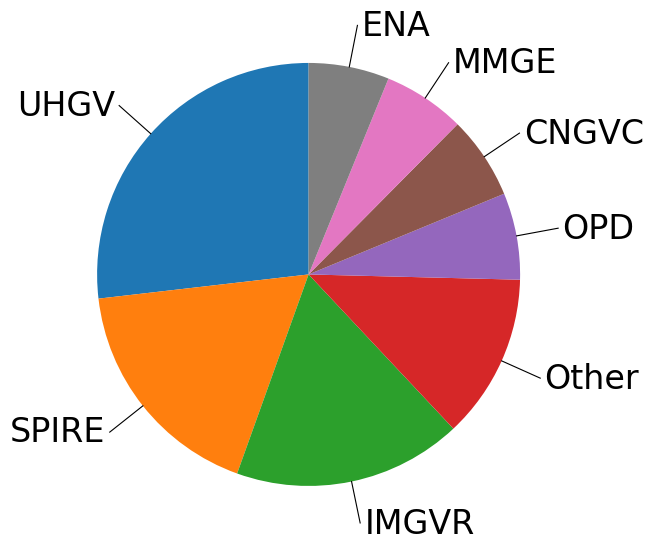

In [117]:
### figure 1c pie chart of source dbs
import matplotlib.pyplot as plt
import numpy as np

source_db_plot = (
    uhvdb_plot_df
    .with_columns(
        pl.when(pl.col('source_db').is_in(['OVD', 'SMGC', 'VMGC', 'LOGAN', 'CHVD', 'CNGVR']))
        .then(pl.lit('Other'))
        .otherwise(pl.col('source_db'))
        .alias('source_db')
    )
    .group_by('source_db')
    .len()
    .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(source_db_plot['len'], startangle=90)

# Uniform connectors + overlap-aware label y positions
r_line = 1.2        # fixed connector endpoint radius
x_pad = 0.02
min_gap = 0.11
y_bounds = (-1.05, 1.05)

def spread_y(points):
    points.sort(key=lambda p: p['y_text'])
    for i in range(1, len(points)):
        points[i]['y_text'] = max(points[i]['y_text'], points[i - 1]['y_text'] + min_gap)
    if not points:
        return
    shift = min(0, y_bounds[1] - points[-1]['y_text']) + max(0, y_bounds[0] - points[0]['y_text'])
    for p in points:
        p['y_text'] += shift
    for i in range(len(points) - 2, -1, -1):
        points[i]['y_text'] = min(points[i]['y_text'], points[i + 1]['y_text'] - min_gap)

pts = []
for w, label in zip(wedges, source_db_plot['source_db'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(th), np.sin(th)
    pts.append({'label': label, 'x': x, 'y': y, 'y_text': r_line * y, 'side': 'right' if x >= 0 else 'left'})

for side in ('right', 'left'):
    spread_y([p for p in pts if p['side'] == side])

for p in pts:
    x_end = r_line * p['x']
    y_end = r_line * p['y']
    ax.plot([p['x'], x_end], [p['y'], y_end], color='black', lw=0.8)  # uniform length

    x_txt = x_end + x_pad if p['side'] == 'right' else x_end - x_pad
    ax.text(
        x_txt, p['y_text'], p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=24,
        bbox=dict(boxstyle='round,pad=0.10', fc='none', ec='none', alpha=0.0),
    )

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

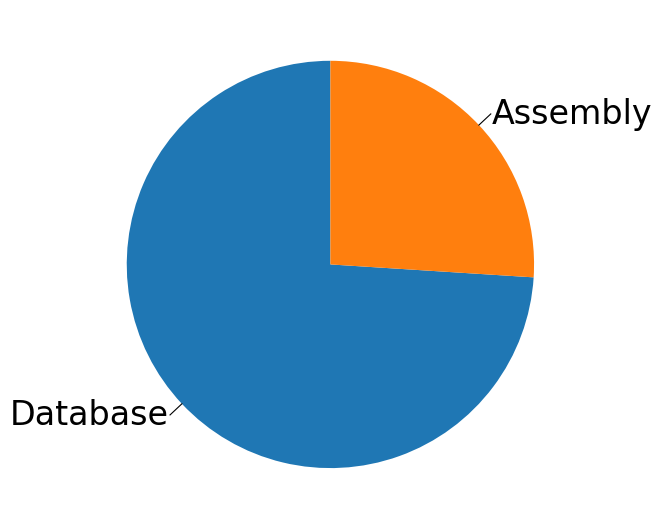

In [113]:
### Figure 1c pie chart of database vs assembly source
import matplotlib.pyplot as plt
import numpy as np

source_type_plot = (
    uhvdb_plot_df
        .with_columns([
            pl.when(pl.col('source_db').is_in(['CNGVC', 'CNGVR', 'UHGV', 'MMGE', 'OPD', 'OVD', 'IMGVR', 'CHVD', 'SMGC', 'VMGC']))
                .then(pl.lit('Database'))
                .otherwise(pl.lit('Assembly'))
                .alias('db_type')
        ])
        .group_by('db_type')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(source_type_plot['len'], startangle=90)

# Shorter connectors + more vertical label placement
r_line = 1.08
x_pad = 0.005
min_gap = 0.14
y_bounds = (-1.18, 1.18)

def spread_y(points):
    points.sort(key=lambda p: p['y_text'])
    for i in range(1, len(points)):
        points[i]['y_text'] = max(points[i]['y_text'], points[i - 1]['y_text'] + min_gap)
    if not points:
        return
    shift = min(0, y_bounds[1] - points[-1]['y_text']) + max(0, y_bounds[0] - points[0]['y_text'])
    for p in points:
        p['y_text'] += shift
    for i in range(len(points) - 2, -1, -1):
        points[i]['y_text'] = min(points[i]['y_text'], points[i + 1]['y_text'] - min_gap)

pts = []
for w, label in zip(wedges, source_type_plot['db_type'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(th), np.sin(th)
    pts.append({'label': label, 'x': x, 'y': y, 'y_text': r_line * y, 'side': 'right' if x >= 0 else 'left'})

for side in ('right', 'left'):
    spread_y([p for p in pts if p['side'] == side])

for p in pts:
    x_end = r_line * p['x']
    y_end = r_line * p['y']
    ax.plot([p['x'], x_end], [p['y'], y_end], color='black', lw=0.8)

    x_txt = x_end + x_pad if p['side'] == 'right' else x_end - x_pad
    ax.text(
        x_txt, p['y_text'], p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=24,
        bbox=dict(boxstyle='round,pad=0.10', fc='none', ec='none', alpha=0.0),
    )

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

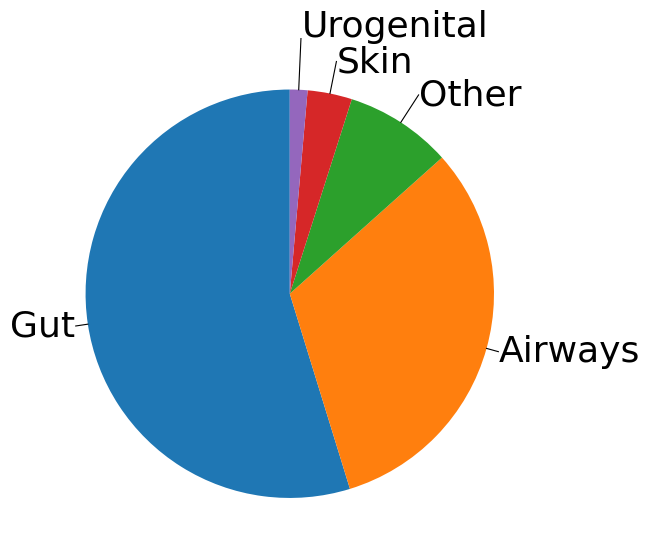

In [162]:
### figure 1c pie chart of body site
import matplotlib.pyplot as plt
import numpy as np

body_site_plot = (
    uhvdb_plot_df
        .group_by('body_site')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 26})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(body_site_plot['len'], startangle=90)

# Short radial connectors with labels at connector endpoints
r_line = 1.06
x_pad = 0.003

# Push specific labels farther from pie
label_radius_add = {
    'Urogenital': 0.25,
    'Skin': 0.1,
    'Other': 0.1,
}

pts = []
for w, label in zip(wedges, body_site_plot['body_site'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(th), np.sin(th)
    r_end = r_line + label_radius_add.get(label, 0.0)
    pts.append({'label': label, 'x': x, 'y': y, 'r_end': r_end, 'side': 'right' if x >= 0 else 'left'})

for p in pts:
    x_end = p['r_end'] * p['x']
    y_end = p['r_end'] * p['y']

    # radial segment ends at the label anchor
    ax.plot([p['x'], x_end], [p['y'], y_end], color='black', lw=0.8)

    x_txt = x_end + x_pad if p['side'] == 'right' else x_end - x_pad
    ax.text(
        x_txt, y_end, p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=26,
        bbox=dict(boxstyle='round,pad=0.10', fc='none', ec='none', alpha=0.0),
    )

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

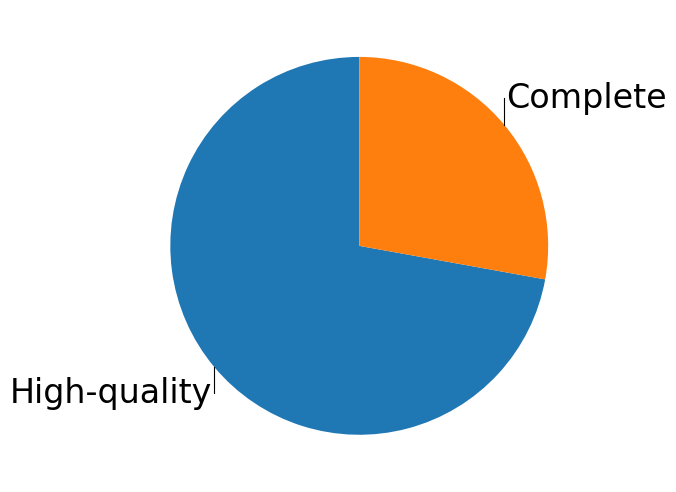

In [111]:
### figure 1c pie chart of CheckV quality
import matplotlib.pyplot as plt
import numpy as np

checkv_quality_plot = (
    uhvdb_plot_df
        .group_by('checkv_quality')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
wedges, _ = ax.pie(checkv_quality_plot['len'], startangle=90)

# Straight vertical connectors only
v_len = 0.14
x_pad = 0.01

pts = []
for w, label in zip(wedges, checkv_quality_plot['checkv_quality'].to_list()):
    th = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = np.cos(th), np.sin(th)
    y_anchor = y + (v_len if y >= 0 else -v_len)
    pts.append({'label': label, 'x': x, 'y': y, 'y_anchor': y_anchor, 'side': 'right' if x >= 0 else 'left'})

for p in pts:
    # short vertical line from slice edge
    ax.plot([p['x'], p['x']], [p['y'], p['y_anchor']], color='black', lw=0.8)

    x_txt = p['x'] + x_pad if p['side'] == 'right' else p['x'] - x_pad
    ax.text(
        x_txt, p['y_anchor'], p['label'],
        ha='left' if p['side'] == 'right' else 'right',
        va='center',
        fontsize=24,
        bbox=dict(boxstyle='round,pad=0.10', fc='none', ec='none', alpha=0.0),
    )

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [166]:
### Join UHVDB metadata with seqhasher to identify unique sequences
seqhasher = (
    pl.read_csv('uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')
        .with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id")).alias('original_id2'))
)

uhvdb_hash1 = uhvdb_plot_df.join(seqhasher[['original_id', 'hash']], left_on='seq_name', right_on='original_id', how='inner')
uhvdb_all_hash = (
    pl.concat([
        uhvdb_hash1,
        uhvdb_plot_df.filter(~pl.col('seq_name').is_in(set(uhvdb_hash1['seq_name']))).join(seqhasher[['original_id2', 'hash']], left_on='seq_name', right_on='original_id2', how='inner')
    ])
    .unique('seq_name')
)

In [167]:
### Count hashes where body_site is not identical across associated seq_name values
hash_body_site_conflicts = (
    uhvdb_all_hash
        .filter(pl.col('body_site') != 'Other')
        .group_by('hash')
        .agg(pl.col('body_site').n_unique().alias('n_body_sites'))
        .filter(pl.col('n_body_sites') > 1)
 )

print("Number of hash_body_site_conflicts:", hash_body_site_conflicts.height)
print("Number of hashes with multiple seqs:", uhvdb_all_hash.group_by('hash').len().filter(pl.col('len') > 1).height)

Number of hash_body_site_conflicts: 2078
Number of hashes with multiple seqs: 133913


In [168]:
### Identify number of novel, unique, airway viruses
uhvdb_db_hashes = set(uhvdb_all_hash.filter(pl.col('db_type') == 'Database')['hash'])
uhvdb_novel_unique_airway_hashes = (
    uhvdb_all_hash
        .filter(
            (pl.col('body_site') == 'Airways') &
            (~pl.col('hash').is_in(uhvdb_db_hashes))
        )
        .unique('hash')
)
uhvdb_novel_unique_urogenital_hashes = (
    uhvdb_all_hash
        .filter(
            (pl.col('body_site') == 'Urogenital') &
            (~pl.col('hash').is_in(uhvdb_db_hashes))
        )
        .unique('hash')
)
uhvdb_novel_unique_skin_hashes = (
    uhvdb_all_hash
        .filter(
            (pl.col('body_site') == 'Skin') &
            (~pl.col('hash').is_in(uhvdb_db_hashes))
        )
        .unique('hash')
)
print("Number of novel, unique airway hashes:", uhvdb_novel_unique_airway_hashes.height)
print("Number of novel, unique urogenital hashes:", uhvdb_novel_unique_urogenital_hashes.height)
print("Number of novel, unique skin hashes:", uhvdb_novel_unique_skin_hashes.height)

Number of novel, unique airway hashes: 155129
Number of novel, unique urogenital hashes: 2801
Number of novel, unique skin hashes: 11640
